## 06 — Train Patient Satisfaction Predictor

Target: **Patient Satisfaction** — regression (1–10 scale)  
Key insight from EDA: satisfaction correlates **−0.865** with wait time — strongest signal in dataset  
Models: Linear Regression (baseline) → Random Forest → XGBoost (tuned)

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from xgboost import XGBRegressor

from feature_engineering import prepare_with_features

plt.style.use('dark_background')
ACCENT  = '#3b82f6'
PALETTE = ['#3b82f6', '#22c55e', '#f97316', '#a855f7']
print('Libraries loaded')

Libraries loaded


### 1. Load Data

Training samples : 4000
Test samples     : 1000
Target range     : 1.0 – 5.0
Target mean      : 2.77


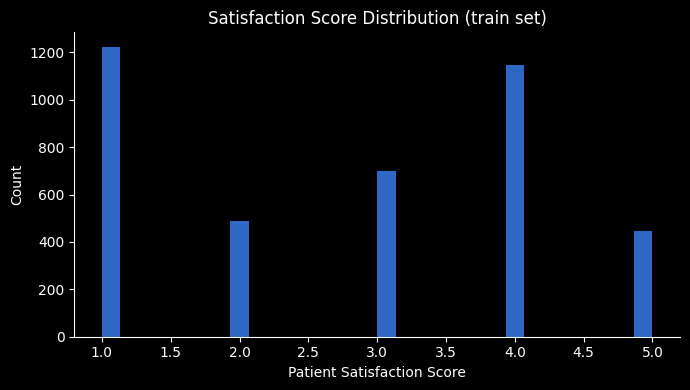

In [2]:
splits = prepare_with_features()
X_train = splits['X_train']
X_test  = splits['X_test']
y_train = splits['y_sat_train']
y_test  = splits['y_sat_test']
feature_names = splits['feature_names']

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Target range     : {y_train.min():.1f} – {y_train.max():.1f}')
print(f'Target mean      : {y_train.mean():.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_train, bins=30, color=ACCENT, alpha=0.8, edgecolor='none')
ax.set_xlabel('Patient Satisfaction Score', color='white')
ax.set_ylabel('Count', color='white')
ax.set_title('Satisfaction Score Distribution (train set)', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 2. Baseline — Linear Regression

In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)
print(f'Linear Regression  →  RMSE: {rmse_lr:.3f}  MAE: {mae_lr:.3f}  R²: {r2_lr:.4f}')

Linear Regression  →  RMSE: 0.571  MAE: 0.453  R²: 0.8407


### 3. Random Forest

In [4]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)
print(f'Random Forest  →  RMSE: {rmse_rf:.3f}  MAE: {mae_rf:.3f}  R²: {r2_rf:.4f}')

Random Forest  →  RMSE: 0.501  MAE: 0.371  R²: 0.8773


### 4. XGBoost + Hyperparameter Tuning

In [5]:
xgb = XGBRegressor(n_estimators=300, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)
print(f'XGBoost (default)  →  RMSE: {rmse_xgb:.3f}  MAE: {mae_xgb:.3f}  R²: {r2_xgb:.4f}')

# CV
cv = cross_val_score(xgb, X_train, y_train, cv=5,
                     scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f'XGBoost CV RMSE: {-cv.mean():.3f} ± {cv.std():.3f}')

XGBoost (default)  →  RMSE: 0.535  MAE: 0.406  R²: 0.8603
XGBoost CV RMSE: 0.559 ± 0.012


In [6]:
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}
grid = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)
print(f'Best params: {grid.best_params_}')
print(f'Best CV RMSE: {-grid.best_score_:.3f}')

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE: 0.498


### 5. Final Evaluation

In [7]:
best_model  = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best  = mean_absolute_error(y_test, y_pred_best)
r2_best   = r2_score(y_test, y_pred_best)

summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost (default)', 'XGBoost (tuned)'],
    'RMSE':  [rmse_lr, rmse_rf, rmse_xgb, rmse_best],
    'MAE':   [mae_lr,  mae_rf,  mae_xgb,  mae_best],
    'R²':    [r2_lr,   r2_rf,   r2_xgb,   r2_best],
}).sort_values('RMSE')
summary[['RMSE','MAE','R²']] = summary[['RMSE','MAE','R²']].round(4)
print(summary.to_string(index=False))

            Model   RMSE    MAE     R²
  XGBoost (tuned) 0.4700 0.3633 0.8921
    Random Forest 0.5012 0.3712 0.8773
XGBoost (default) 0.5347 0.4059 0.8603
Linear Regression 0.5710 0.4531 0.8407


### 6. Feature Importance + Actual vs Predicted

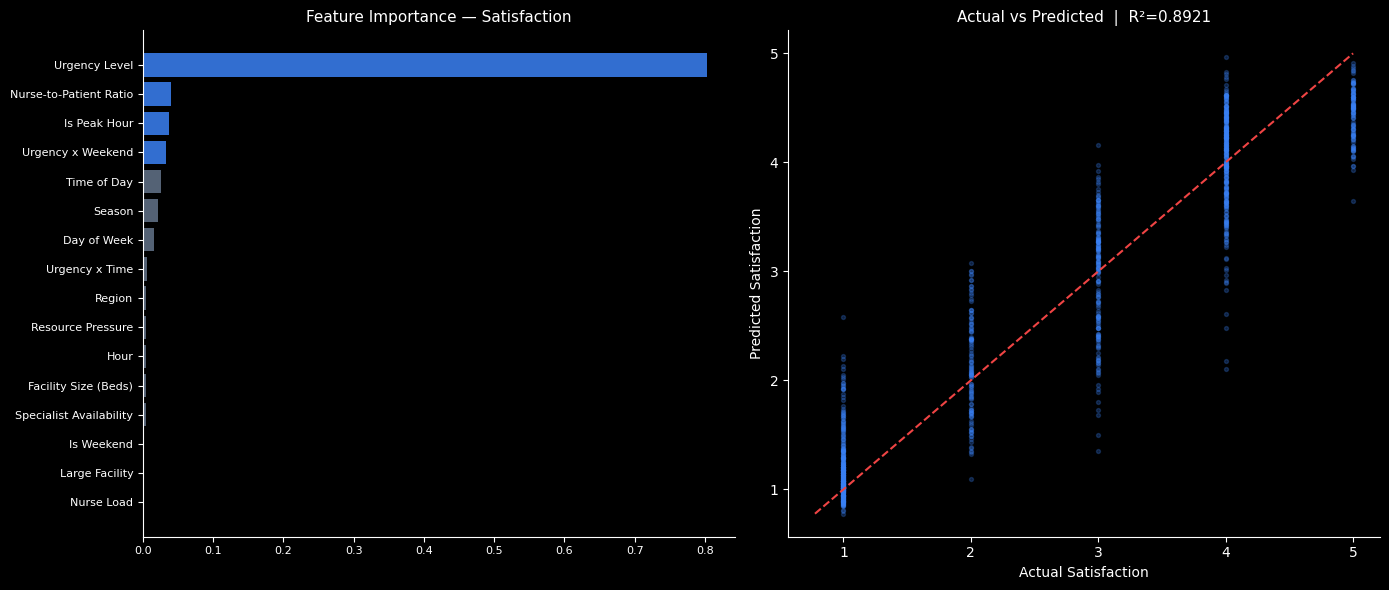

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Feature importance
fi_df = pd.DataFrame({'feature': feature_names,
                       'importance': best_model.feature_importances_}).sort_values('importance')
colors = [ACCENT if v > fi_df['importance'].quantile(0.75) else '#64748b'
          for v in fi_df['importance']]
axes[0].barh(fi_df['feature'], fi_df['importance'], color=colors, alpha=0.85)
axes[0].set_title('Feature Importance — Satisfaction', color='white', fontsize=11)
axes[0].tick_params(colors='white', labelsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Actual vs Predicted
axes[1].scatter(y_test, y_pred_best, alpha=0.25, s=8, color=ACCENT)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[1].plot(lims, lims, '--', color='#ef4444', linewidth=1.5)
axes[1].set_xlabel('Actual Satisfaction', color='white')
axes[1].set_ylabel('Predicted Satisfaction', color='white')
axes[1].set_title(f'Actual vs Predicted  |  R²={r2_best:.4f}', color='white', fontsize=11)
axes[1].tick_params(colors='white')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

### 7. Save Model

In [9]:
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

save_path = os.path.join(models_dir, 'satisfaction_model.pkl')
joblib.dump({'model': best_model, 'feature_names': feature_names}, save_path)

print(f'Saved: {save_path}')
print(f'RMSE : {rmse_best:.4f}')
print(f'MAE  : {mae_best:.4f}')
print(f'R²   : {r2_best:.4f}')

Saved: ..\models\satisfaction_model.pkl
RMSE : 0.4700
MAE  : 0.3633
R²   : 0.8921
